In [1]:
import os
import sys

from corner import corner
from copy import deepcopy 

sys.path.append('..')

from src.simulator import Model, BurstSimulator
from src.flow_matching.simulator import Model as BatchedModel

from src.c2st import c2st
from src.flow_matching.loader import empty_classifier_from_config, empty_model_from_config, read_config, prob_path_from_config
from src.flow_matching.distributions import UniformPrior, CompositePrior, Posterior, DiscreteUniform, StandardGaussian
from src.flow_matching.probability_path import GuidedLinearProbabilityPath
from src.flow_matching.integration import EulerODESolver
from src.flow_matching.models import MLPGuidedVectorField, FRBLightCurveCNN, LightCurveThinner, fourier_embedding, LightCurveMLP, UNetEncoder, TransdimensionalModel, EncodedClassifier
from src.flow_matching.transformer import TransformerGuidedField
from src.helpers import record_every, plot_posterior_samples, gen_parameter_labels

import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.lines as mlines

import numpy as np
import torch
import yaml

from src.flow_matching.plotting import plot_loss, plot_snapshots
from src.flow_matching.helpers import choose_device, build_mlp, find_run_dir

device = choose_device()

# Loading the trained FM model

In [2]:
# fill in desired job_id or directory name 
job_id = "15102039"
run_dir = None
save_dir = "../checkpoints/"

In [3]:
# find the right directory (via run_id, or path)
run_dir = find_run_dir(job_id, save_dir) if job_id else os.path.join(save_dir, run_dir)

checkpoint_path = os.path.join(run_dir, 'training_checkpoint.pth')
config_path     = os.path.join(run_dir, 'config.yaml')

# create empty model from config
config = read_config(config_path)
vector_field = empty_model_from_config(config)

/home/nvandermeulen/miniconda3/envs/FRB/lib/python3.10/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [4]:
transdimensional = not config['training']['fixed_N'] 
print(transdimensional)
if transdimensional:
    classifier = empty_classifier_from_config(config)
    vector_field = TransdimensionalModel(classifier, vector_field)

True


In [5]:
# load trained model 
print(checkpoint_path)
checkpoint = torch.load(checkpoint_path, weights_only=False)

# Load 'normal' or EMA version 
ema = False
if ema:
    EMA_checkpoint_path = os.path.join(run_dir, "EMA_checkpoint.pth")
    state_dict = torch.load(EMA_checkpoint_path, weights_only=False)
    vector_field.load_state_dict(state_dict) 
else:
    vector_field.load_state_dict(checkpoint["model_state_dict"])

vector_field.eval()
vector_field.to(device)

losses = checkpoint["losses"]

../checkpoints/15102039_run_04_10_1728/training_checkpoint.pth


In [6]:
# load probability path used
path = prob_path_from_config(config)
prior = path.p_data.prior

# parameters to infer and (max) number of components in training data
inf_params = config['model']['init_params']['inf_params']
N = path.p_data.model_params['ncomp']

# dimension of parameter vector 
vector_dim = N * len(inf_params)

# standard setting of burst parameters
burstparams = path.p_data.model_params['burstparams']

# mean and std of parameters for standardization
try:
    mean, std = torch.tensor(config['training']['sample_mean'], device=device), torch.tensor(config['training']['sample_std'], device=device)
except KeyError:
    mean, std = torch.zeros(vector_dim, device=device), torch.ones(vector_dim, device=device)

{'model_params': {'ncomp': 5, 'burstparams': {'t0': [0.20000000298023224, 0.3500000238418579, 0.5, 0.6499999761581421, 0.800000011920929], 'amp': [2.0, 2.0, 2.0, 2.0, 2.0], 'rise': [-1.5228787660598755, -1.5228787660598755, -1.5228787660598755, -1.5228787660598755, -1.5228787660598755], 'skew': [5.0, 5.0, 5.0, 5.0, 5.0]}, 'ybkg': 5.0, 'time': tensor([0.0000, 0.0010, 0.0020, 0.0030, 0.0040, 0.0050, 0.0060, 0.0070, 0.0080,
        0.0090, 0.0100, 0.0110, 0.0120, 0.0130, 0.0140, 0.0150, 0.0160, 0.0170,
        0.0180, 0.0190, 0.0200, 0.0210, 0.0220, 0.0230, 0.0240, 0.0250, 0.0260,
        0.0270, 0.0280, 0.0290, 0.0300, 0.0310, 0.0320, 0.0330, 0.0340, 0.0350,
        0.0360, 0.0370, 0.0380, 0.0390, 0.0400, 0.0410, 0.0420, 0.0430, 0.0440,
        0.0450, 0.0460, 0.0470, 0.0480, 0.0490, 0.0501, 0.0511, 0.0521, 0.0531,
        0.0541, 0.0551, 0.0561, 0.0571, 0.0581, 0.0591, 0.0601, 0.0611, 0.0621,
        0.0631, 0.0641, 0.0651, 0.0661, 0.0671, 0.0681, 0.0691, 0.0701, 0.0711,
        0.0721,

# Simulating a burst to do inference on
We simulate a burst that we would like to infer the defining parameter values from. 

This example has N =  3  components

    The burst parameters are:
    t0 =	 [0.25 0.46 0.56]
    log(amp) =	 [1.11 2.28 0.73]
    log(rise) =	 [-1.99 -2.43 -2.12]
    skew =	 [1.98 1.12 3.75]
    


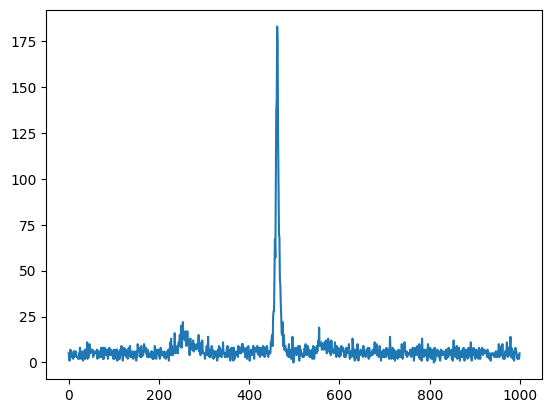

In [7]:
# sample lightcurve to condition on
params, simulated_counts, components = path.p_data.sample(1)
burstparams = prior.samples_as_dict(params)
N_true = components[0][0].item()
print("This example has N = ", components[0][0].item(), " components")
print(
    f"""
    The burst parameters are:
    t0 =\t {np.array_str(burstparams['t0'][0, :components].cpu().numpy(), precision=2, suppress_small=True)}
    log(amp) =\t {np.array_str(burstparams['amp'][0, :components].cpu().numpy(), precision=2, suppress_small=True)}
    log(rise) =\t {np.array_str(burstparams['rise'][0, :components].cpu().numpy(), precision=2, suppress_small=True)}
    skew =\t {np.array_str(burstparams['skew'][0, :components].cpu().numpy(), precision=2, suppress_small=True)}
    """
)
simulated_counts = simulated_counts[0]
plt.plot(simulated_counts.cpu().numpy())
plt.show()

# Using the model to generate a FM posterior 

## Sampling FM posterior $p^\phi(\theta \mid y, N$)

In [8]:
num_samples = 1000  # number of prior samples to transform 
samples_per_batch = 1000
batches = num_samples // samples_per_batch

# allocate space for samples
final_snapshot = torch.zeros((batches * samples_per_batch, vector_dim), device=device)
Ns = torch.zeros((batches * samples_per_batch, 1), device=device)

# condition all prior samples on the same burst profile
condition = torch.tensor(simulated_counts / 150, device=device, dtype=torch.float)
simulations = condition.repeat(samples_per_batch, 1)

# initialize ODE solver
solver = EulerODESolver(vector_field)
nts = 200 # integration steps
ts = torch.linspace(0, 1, nts).to(device)

if transdimensional:
    logits = classifier(condition.unsqueeze(0))
    p_N = torch.softmax(logits, dim=1).flatten()
else:
    p_N = torch.zeros(N, device=device)
    p_N[N-1] = 1
    
# integrate in batches
for i in range(batches):

    start = i * samples_per_batch
    stop = start + samples_per_batch

    N_samples = torch.multinomial(p_N.repeat(samples_per_batch, 1), num_samples=1) + 1

    x0 = path.p_simple.sample(samples_per_batch, Ns=N_samples).to(device) 

    Ns[start:stop, :] = N_samples

    # solve ODE starting from x0
    final_snapshot[start:stop, :] = solver.solve(x0, ts.view(1, nts, 1).expand(samples_per_batch, nts, 1), y=simulations, N=N_samples) * std + mean

/scratch-local/nvandermeulen.17696752/ipykernel_1248920/4291172279.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  condition = torch.tensor(simulated_counts / 150, device=device, dtype=torch.float)
100%|██████████| 199/199 [00:02<00:00, 94.20it/s]


## classifier results

True number of components is:  3
Most likely estimate from classifier:  3


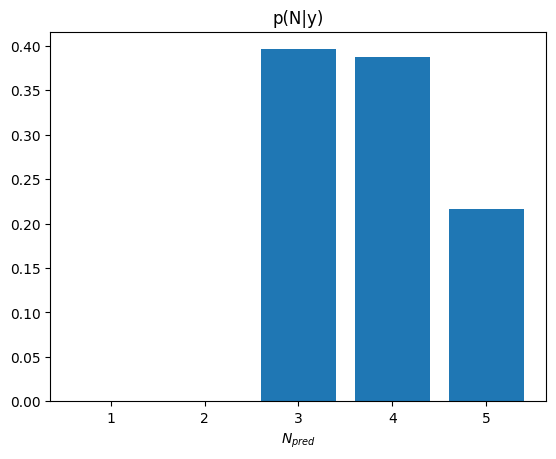

In [9]:
plt.bar(range(1, len(p_N.cpu().detach().numpy())+1), height=p_N.cpu().detach().numpy())
plt.xlabel("$N_{pred}$")
plt.title('p(N|y)')

print("True number of components is: ", components[0][0].item())
print("Most likely estimate from classifier: ", range(1, len(p_N.cpu().detach().numpy())+1)[torch.where(p_N == torch.max(p_N))[0]])

# plotting the samples

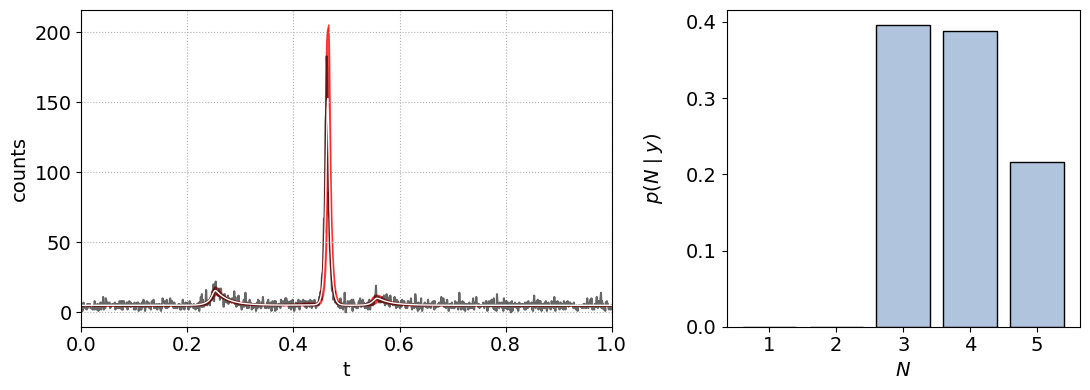

In [10]:
# convert sampled parameter vectors to dictionary
posterior_param_samples = path.p_data.prior.samples_as_dict(final_snapshot)

# simulate burst profiles from sampled parameters and components
posterior_curve_samples = BatchedModel(
    device=device, 
    **{
        'time':torch.linspace(0, 1, simulated_counts.shape[0]), 
        'burstparams':posterior_param_samples,
        'ybkg':5,
        'ncomp':Ns
        }
        ).get_flux()

import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(11, 4))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 1])  # first subplot wider

ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

ax1.plot(np.linspace(0, 1, simulated_counts.shape[0]), simulated_counts.flatten().cpu(),'k-', alpha=0.6,  label='observed flux')
sample_colors=['pink', 'yellow', 'orange', 'purple', 'green', 'cyan', 'red', 'grey', 'magenta', 'blue']

# plot mean curve
mean_profile = torch.mean(posterior_curve_samples[0:num_samples], dim=0).cpu()
time_ = np.linspace(0, 1, simulated_counts.shape[0])
ax1.plot(time_, mean_profile, color='white', label='mean profile', linewidth=1)

# plot 95th percentile
q1 = torch.quantile(posterior_curve_samples, 0.025, dim=0).cpu()
q3 = torch.quantile(posterior_curve_samples, 0.975, dim=0).cpu()
iqr = q3 - q1
ax1.fill_between(time_, q1, q3, color='red', alpha=0.7, label='std profile')

ax1.grid(linestyle='dotted')
ax1.set_ylabel('counts', fontsize=14)
ax1.set_xlabel('t', fontsize=14)
ax1.set_xlim(0,1)
ax1.tick_params(axis='both', labelsize=14)

ax2.bar(
    range(1, len(p_N.cpu().detach().numpy())+1), 
    height=p_N.cpu().detach().numpy(), 
    color='lightsteelblue', 
    edgecolor='black',    
    linewidth=1,
    label=range(1, N+1)
    )
ax2.set_xlabel("$N$", fontsize=14)
ax2.set_ylabel('$p(N\mid y)$', fontsize=14, labelpad=15)
ax2.tick_params(axis='both', labelsize=14)

# integer tick labels for histogram
import matplotlib.ticker as mticker
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()